# Understand The Problem Statement And Business Case

The World Happiness Report clustering project applies unsupervised machine learning techniques to group countries based on factors that influence quality of life, such as economic production, social support, life expectancy, freedom, generosity, and corruption levels. By analyzing these indicators, the model identifies similarities among nations without using predefined labels, helping researchers better understand global happiness patterns. The happiness scores are collected through surveys in which individuals rate their lives on a scale from 0 (worst possible life) to 10 (best possible life). This type of clustering analysis is useful for discovering trends, comparing regions, and supporting public policies aimed at improving well-being and living conditions around the world.


# Import Datasets And Libraries

In [ ]:
# Get the required dependencies
!pip install bubbly
!pip install iplot
!pip install chart_studio

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from chart_studio.plotly import plot, iplot
from plotly.offline import iplot

In [51]:
df = pd.read_csv('data/happiness_report.csv')

In [52]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [54]:
brazil = df[df['Country or region'] == 'Brazil']
brazil.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
31,32,Brazil,6.3,1.004,1.439,0.802,0.39,0.099,0.086


In [56]:
len(df)

156

# Perform Exploratory Data Analysis

In [55]:
# Check the number of non-null values in the dataframe
print(df.count())

Overall rank                    156
Country or region               156
Score                           156
GDP per capita                  156
Social support                  156
Healthy life expectancy         156
Freedom to make life choices    156
Generosity                      156
Perceptions of corruption       156
dtype: int64


In [ ]:
# Check Null values
df.isnull().sum()

In [ ]:
print(df.describe())

In [20]:
# check the number of duplicated entries in the dataframe
print(df.duplicated().sum())
 # since there are no duplicates, no further action is required

0


In [22]:
# country with the highest score
df.loc[df['Score'].idxmax(), 'Country or region']

'Finland'

# Perform Data Visualization

<Figure size 2000x2000 with 0 Axes>

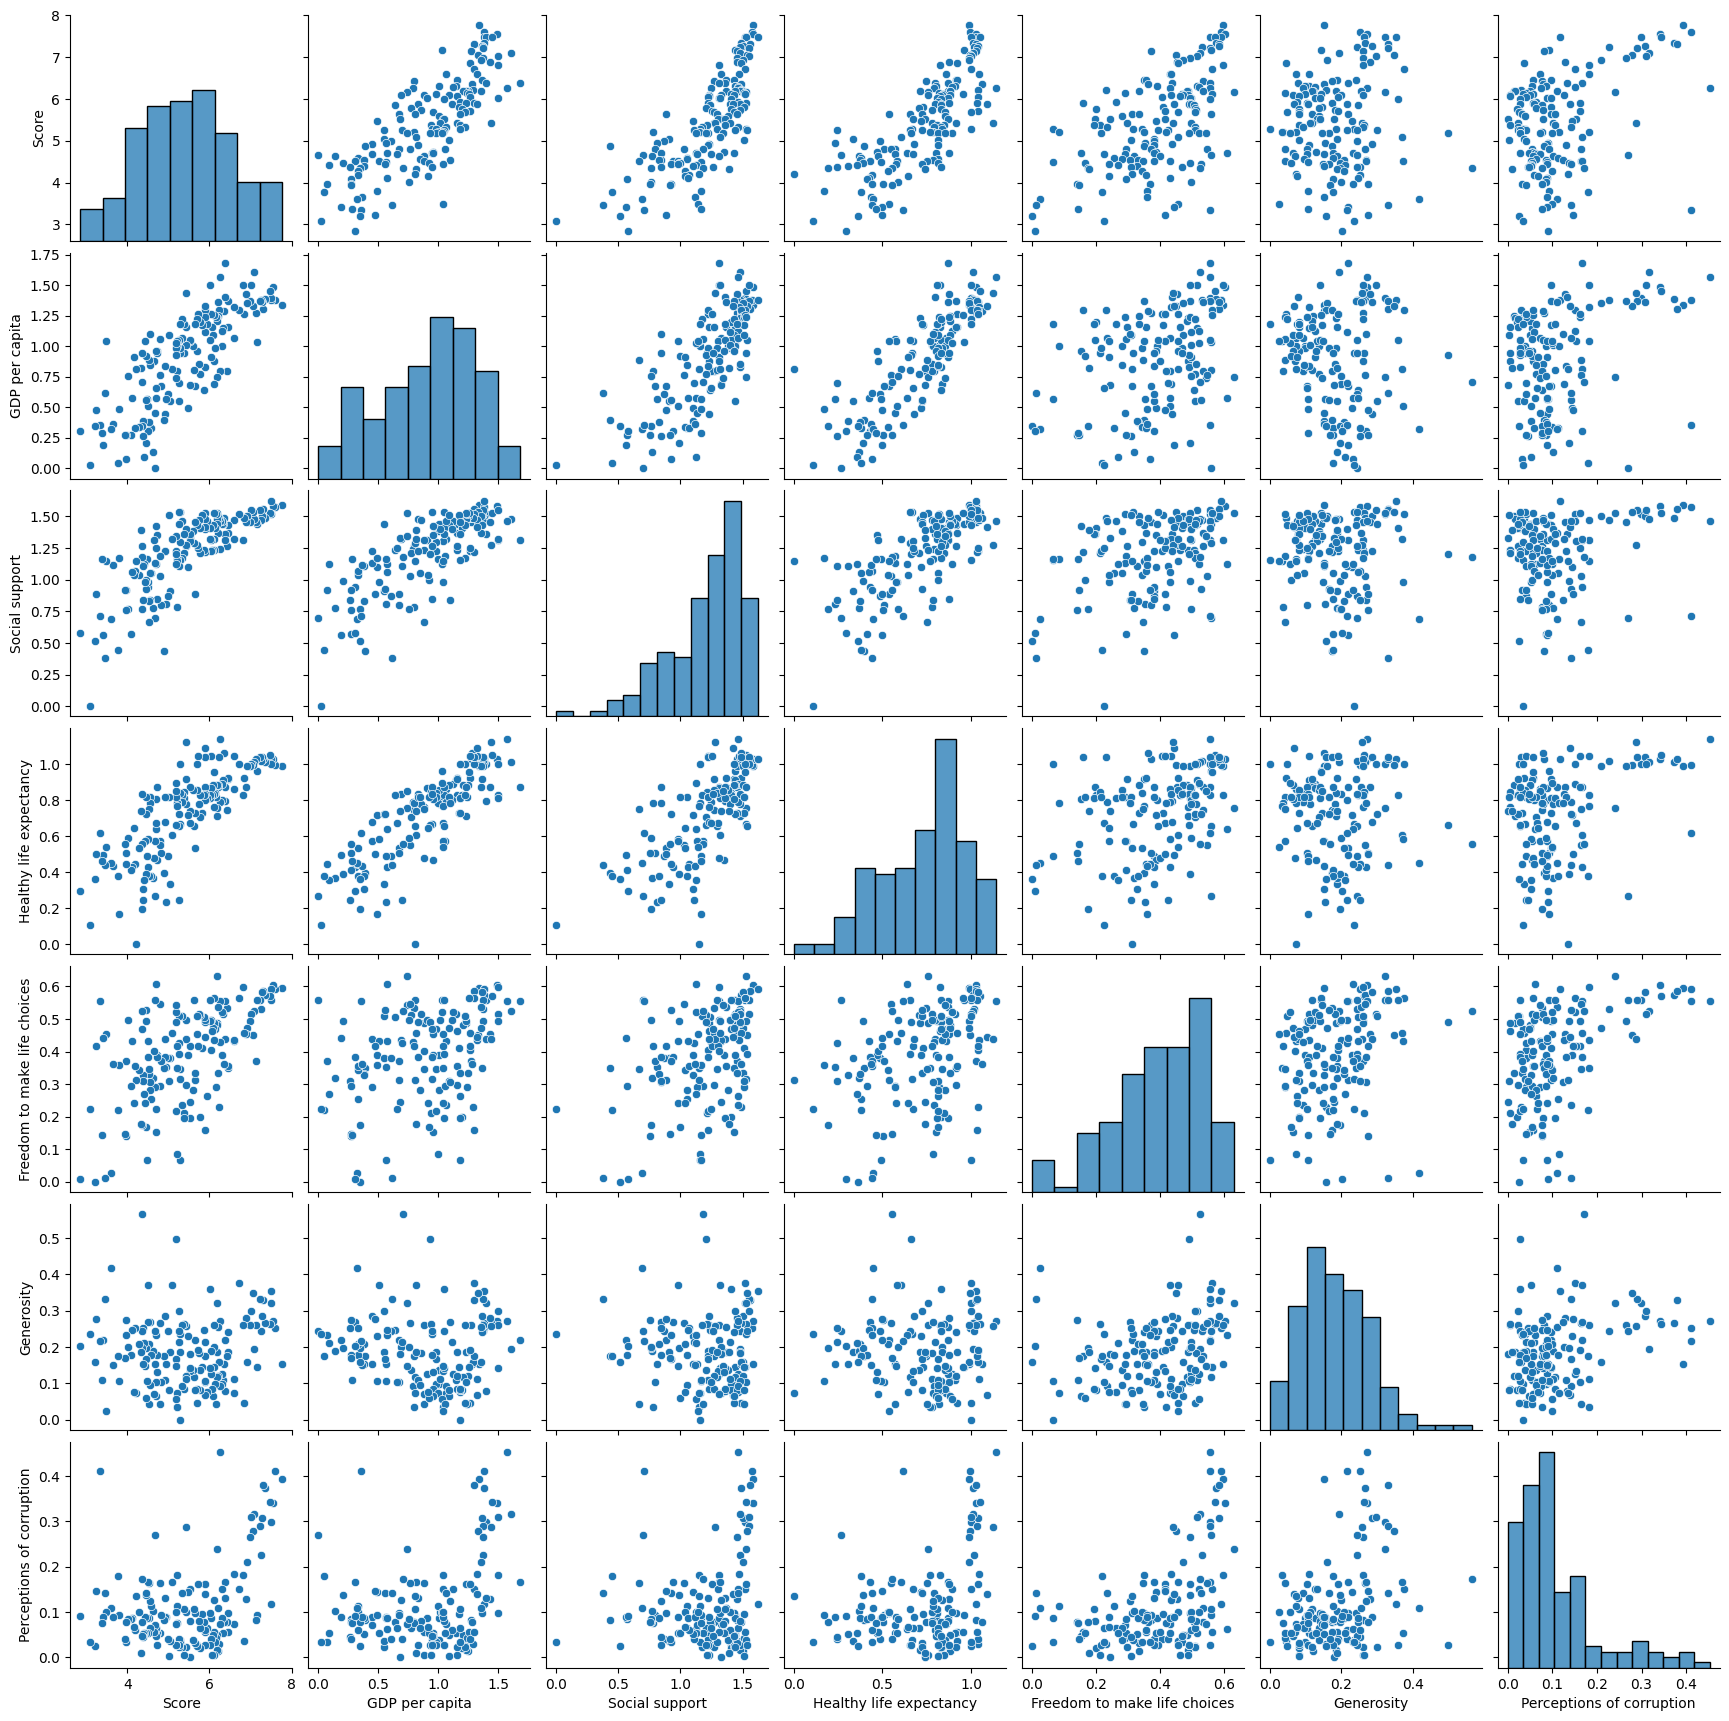

In [58]:
# Plot the pairplot
fig = plt.figure(figsize = (20,20))
sns.pairplot(df[['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']])

# Positive correlation between GDP and score 
# Positive correlation between Social Support and score 

C:\Users\edmoc\AppData\Local\Temp\ipykernel_32240\1331739803.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns[i]], color = 'r');
C:\Users\edmoc\AppData\Local\Temp\ipykernel_32240\1331739803.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns[i]], color = 'r');
C:\Users\e

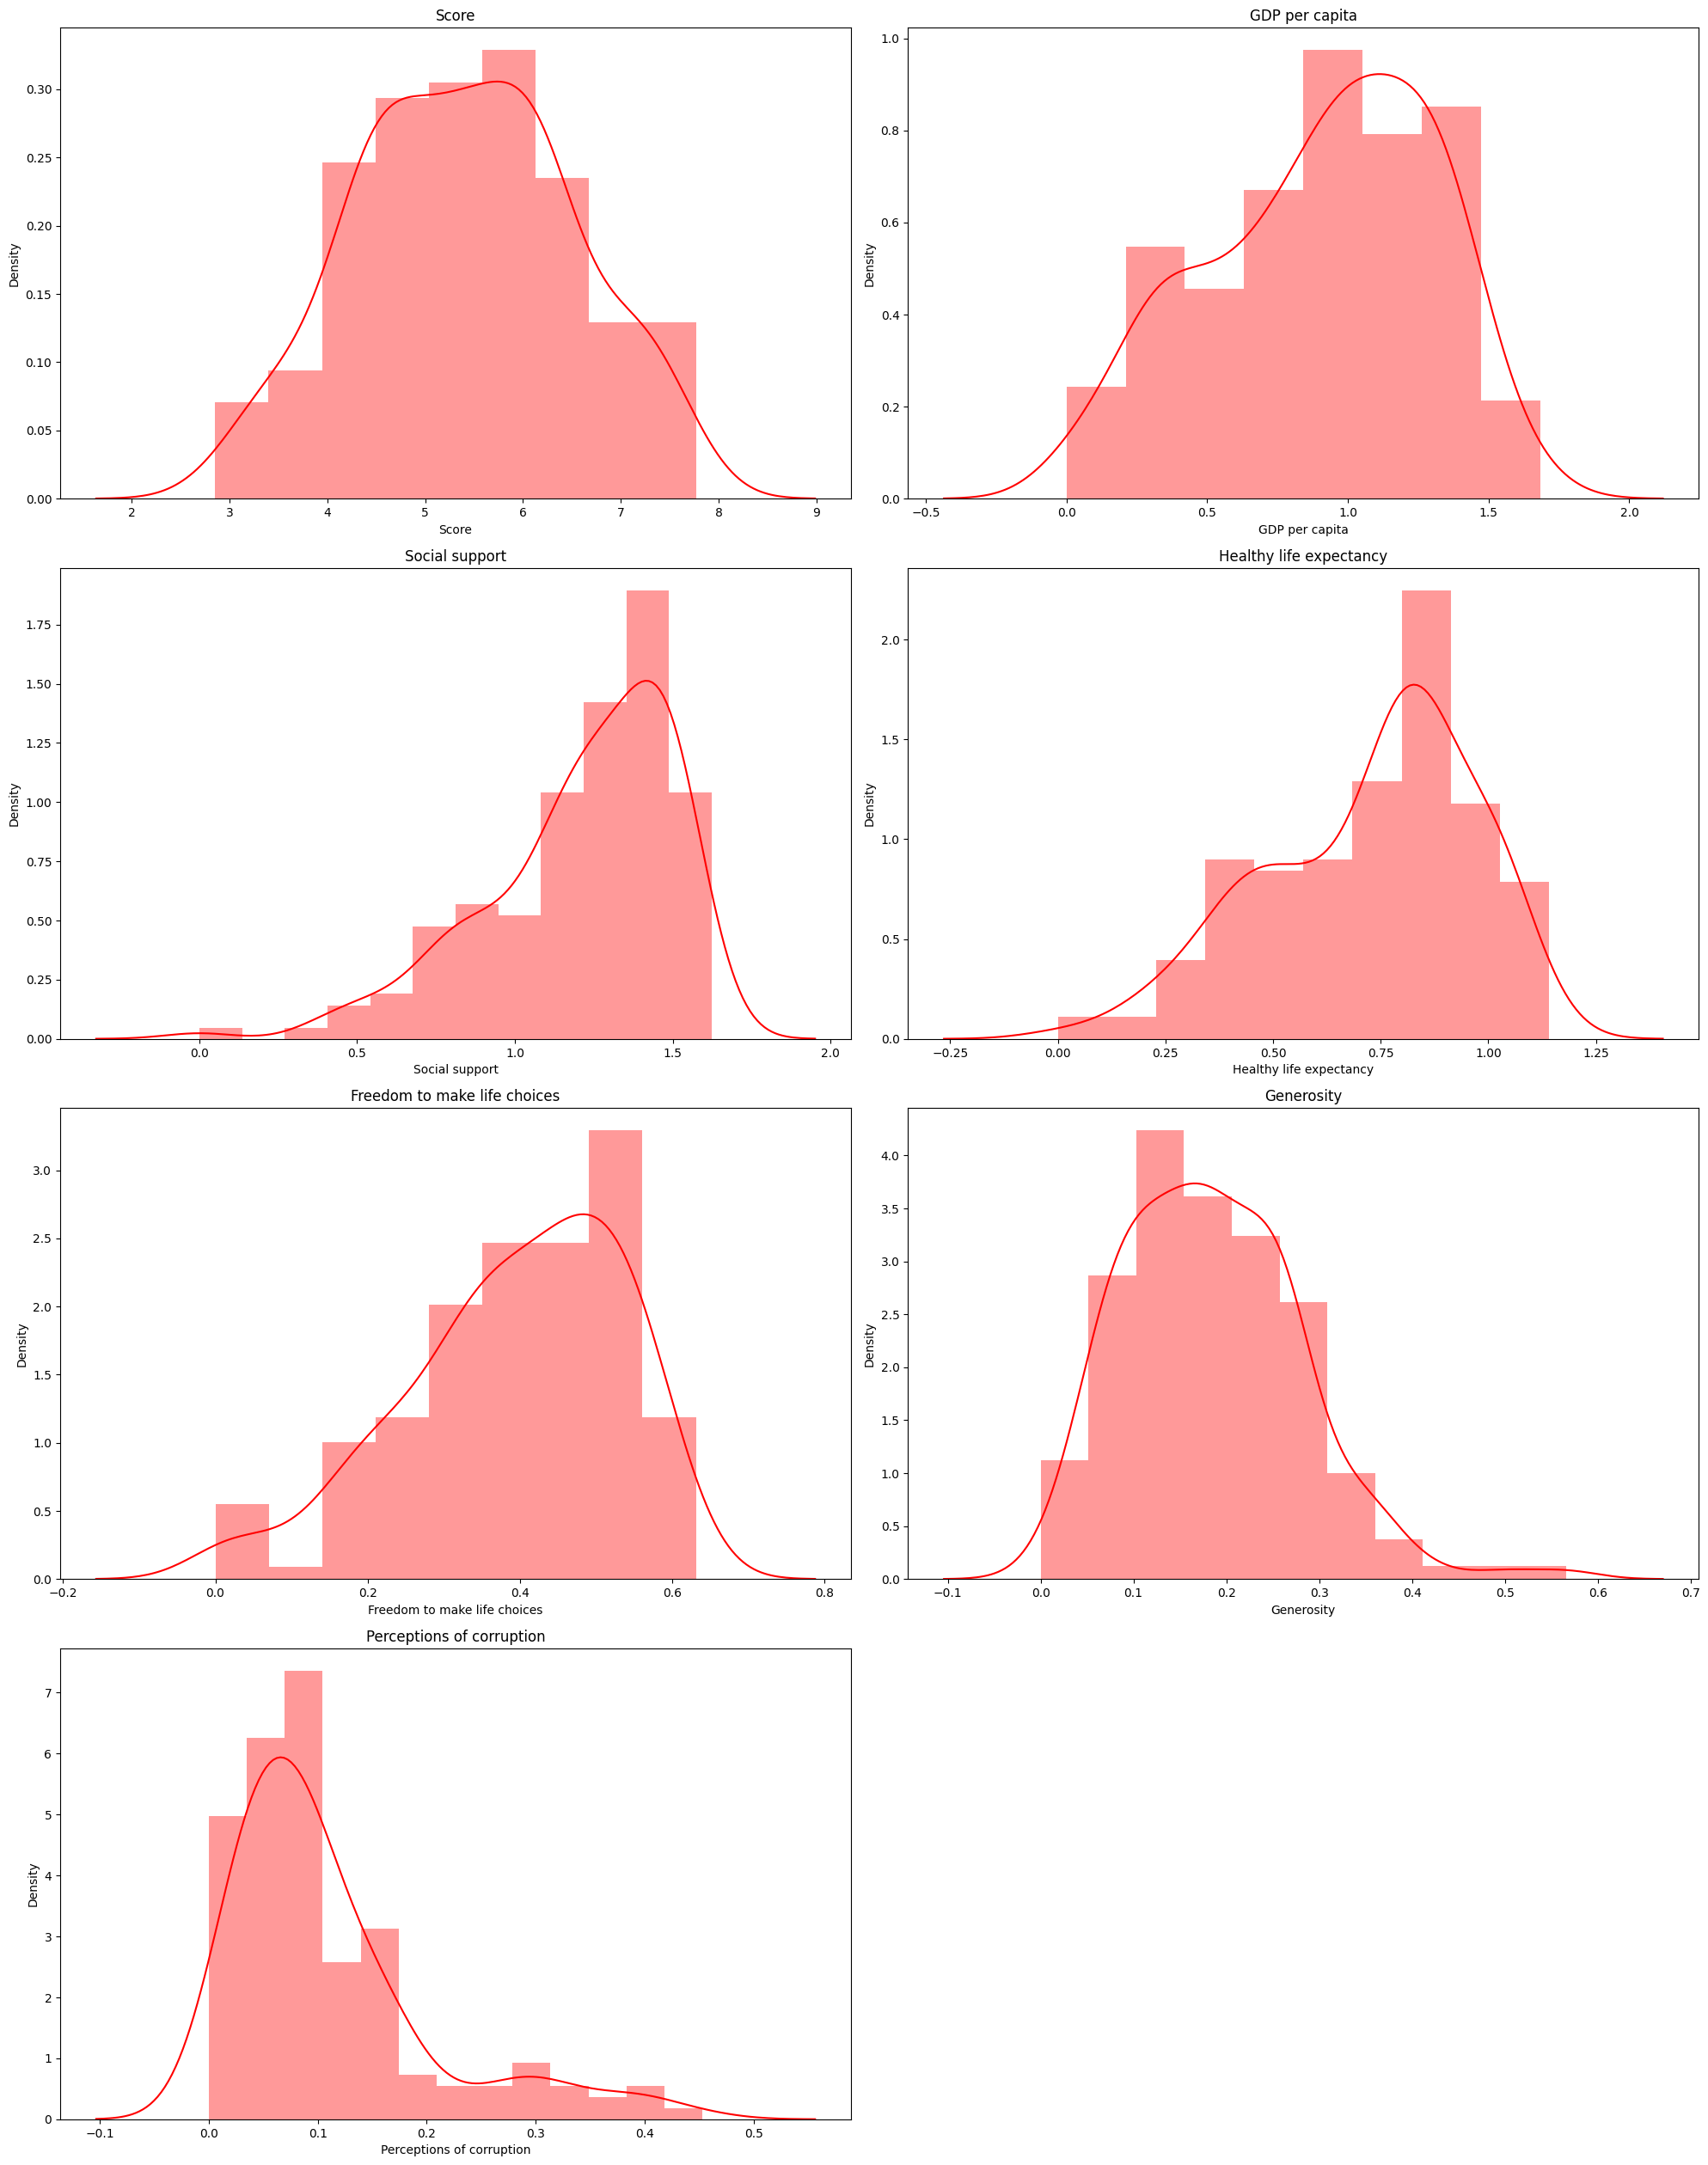

In [60]:
# distplot combines the matplotlib.hist function with seaborn kdeplot()
columns = ['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']
plt.figure(figsize = (20, 50))
for i in range(len(columns)):
  plt.subplot(8, 2, i+1)
  sns.distplot(df[columns[i]], color = 'r');
  plt.title(columns[i])

plt.tight_layout()

In [29]:
df.select_dtypes(include=['float64', 'int64']).corr()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
Score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP per capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Healthy life expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom to make life choices,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Perceptions of corruption,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


In [ ]:
# Plot the relationship between score, GDP and region
fig = px.scatter(df,
                 x='GDP per capita',
                 y ='Score',
                 text = 'Country or region')
fig.show()

In [ ]:
# Plot the relationship between score and GDP (while adding color and size)
fig = px.scatter(df,
                 x='GDP per capita',
                 y ='Score',
                 text = 'Country or region',
                 size='Overall rank',
                 color='Country or region')
fig.update_layout(title_text = 'Happiness Score vs GDP per Capita')
fig.show()

In [73]:
# Plot the relationship between score and healthy life expectancy
fig = px.scatter(df,
                x = 'Healthy life expectancy',
                y = "Score",
                size='Overall rank',
                color = "Country or region",
                hover_name = "Country or region",   
                text = 'Country or region',
                trendline="ols")
fig.update_traces (textposition = 'top center')
fig.update_layout (title_text = 'Happiness Score vs Healthy life expectancy')
fig.show()

In [75]:
# Plot the relationship between score and freedom to make life choices

fig = px.scatter(df,
                 x = 'Freedom to make life choices',
                 y = "Score", size = 'Overall rank',
                 color = "Country or region",
                 hover_name = "Country or region",
                 text = 'Country or region',
                 trendline = "ols")
fig.update_layout(title_text = 'Happiness Score vs Freedom to make life choices')
fig.show()

# Prepare The Data To Feed The Clustering Model

In [47]:
# We are going to create clusters without the use of happiness score and rank to see which countries fall under similar clusters
df.drop(['Score', 'Overall rank'], axis=1)

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...
151,Rwanda,0.359,0.711,0.614,0.555,0.217,0.411
152,Tanzania,0.476,0.885,0.499,0.417,0.276,0.147
153,Afghanistan,0.350,0.517,0.361,0.000,0.158,0.025
154,Central African Republic,0.026,0.000,0.105,0.225,0.235,0.035


In [48]:
# Select the data without rank and happiness score
X = df.drop(['Overall rank', 'Score'], axis=1)

# Understand The Intuition Behind K-Means 

# Find The Optimal Number Of Clusters

# Perform Clustering Using K-Means

# Visualize The Clusters